<a href="https://colab.research.google.com/github/sravyamateti/Lab-Assignment/blob/main/DAV_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("earthquake_1995-2023.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [ ]:
print("Exact duplicate rows:",df.duplicated().sum())


Exact duplicate rows: 0


In [ ]:
dupe_mask=df.duplicated(subset=["title","date_time"],keep=False)
print("Rows involved in a title+date duplicate:",dupe_mask.sum())
df[dupe_mask].sort_values("title")[["title","date_time","magnitude","country"]]

Rows involved in a title+date duplicate: 0


,title,date_time,magnitude,country


In [ ]:
befor=len(df)
df=df.drop_duplicates(subset=["title","date_time"],keep="first").reset_index(drop=True)
after=len(df)
print(f"Removed{befor-after} duplicate row(s).")
print("rows now:",after)

Removed2 duplicate row(s).
rows now: 998


In [ ]:
for col in ["cdi","dmin","gap","nst"]:
  zeros=(df[col]==0).sum()
  print(f"{col:6s}:{zeros} zeros ({zeros/len(df)*100:.0f}% of rows)")

cdi   :397 zeros (40% of rows)
dmin  :588 zeros (59% of rows)
gap   :252 zeros (25% of rows)
nst   :519 zeros (52% of rows)


In [ ]:
import numpy as np
for col in ["cdi","gap"]:
   df[col]=df[col].replace(0,np.nan)
print("Mising values now visible:")
print(df[["cdi","gap"]].isnull().sum())

Mising values now visible:
cdi    397
gap    252
dtype: int64


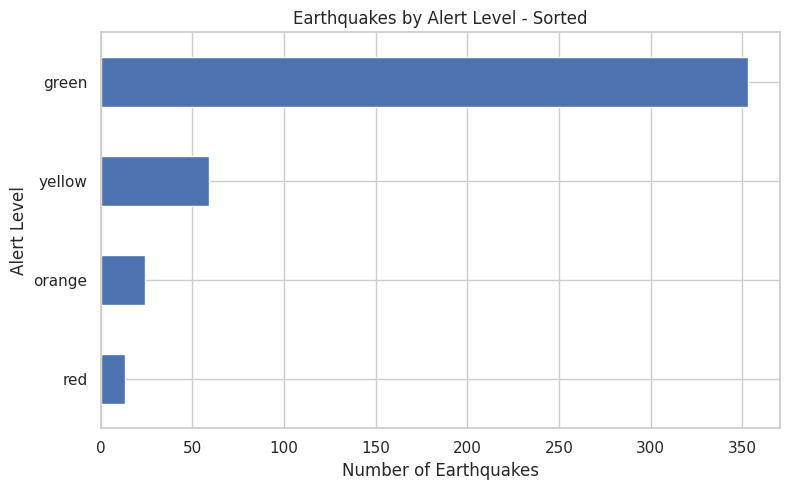

In [ ]:
#Bargraph
alert_counts = df["alert"].value_counts().sort_values()

plt.figure(figsize=(8, 5))
alert_counts.plot(kind="barh")

plt.title("Earthquakes by Alert Level - Sorted")
plt.xlabel("Number of Earthquakes")
plt.ylabel("Alert Level")

plt.tight_layout()
plt.show()

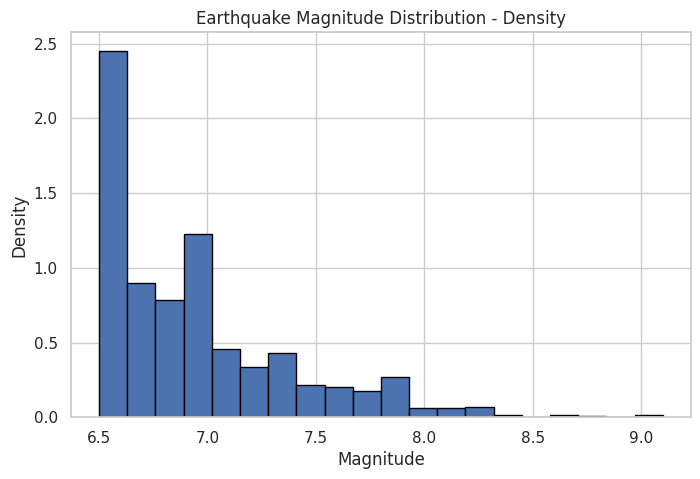

In [ ]:
#Histogram graph
plt.figure(figsize=(8, 5))

plt.hist(
    df["magnitude"].dropna(),
    bins=20,
    density=True,
    edgecolor="black"
)

plt.title("Earthquake Magnitude Distribution - Density")
plt.xlabel("Magnitude")
plt.ylabel("Density")

plt.show()

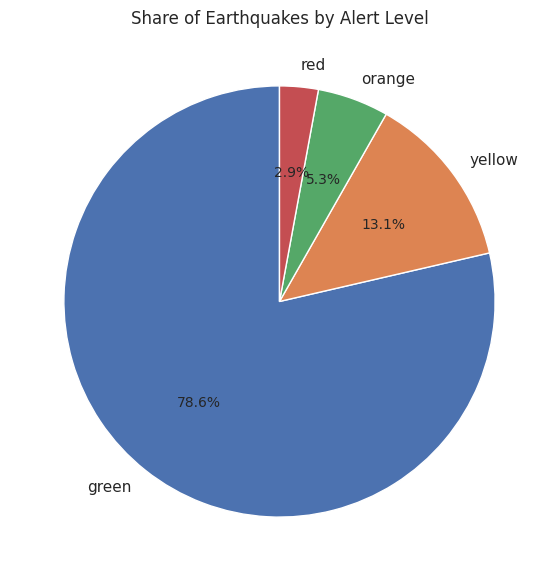

In [ ]:
#Pie chart
alert_counts = df["alert"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Earthquakes by Alert Level")

plt.show()

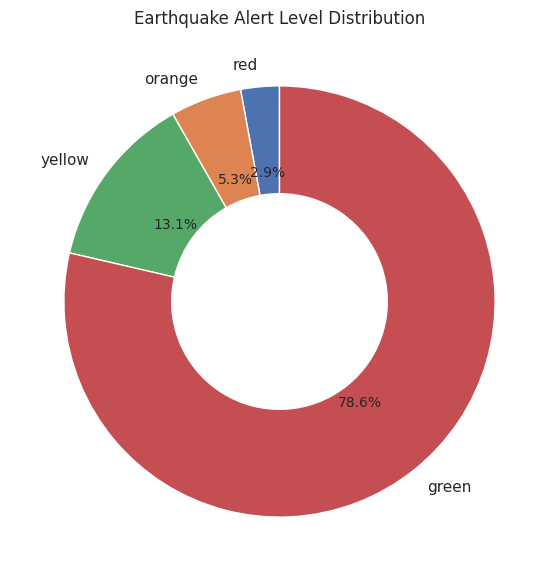

In [ ]:
#Donut chart
plt.figure(figsize=(7, 7))

plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.5}
)

plt.title("Earthquake Alert Level Distribution")

plt.show()

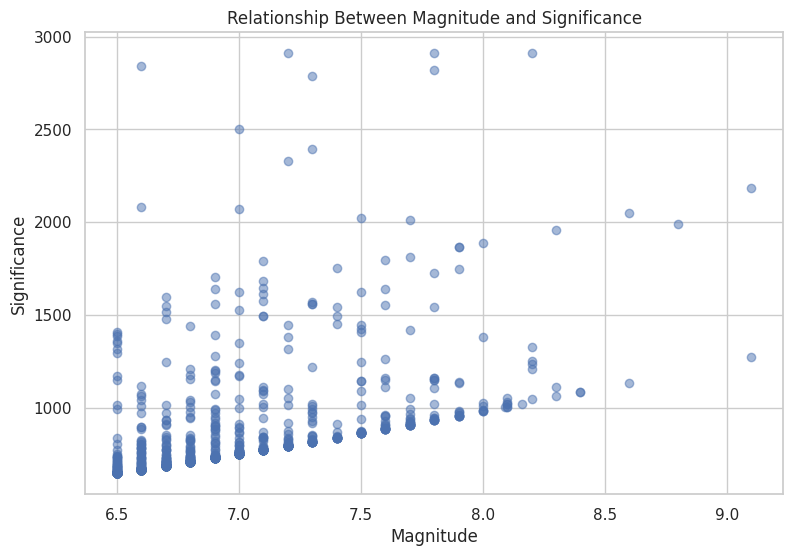

In [ ]:
#scatter plot
plt.figure(figsize=(9, 6))

plt.scatter(
    df["magnitude"],
    df["sig"],
    alpha=0.5
)

plt.title("Relationship Between Magnitude and Significance")
plt.xlabel("Magnitude")
plt.ylabel("Significance")

plt.grid(True)
plt.show()